In [37]:
import pydicom, matplotlib.pyplot as plt, numpy as np
import os
import csv

from pathlib import Path

In [3]:
## Choose dicom folder to explore

In [4]:
print(os.getcwd())

/home/anya.tongprasith001/U54REC


In [5]:
total_dicom = 0
dicom_paths = []
dicom_folder_path = "/raid/data01/deephealth/dh_dcm_ast"
if not os.path.exists(dicom_folder_path):
    print(f"File not found: {dicom_folder_path}")
    print("Please update dicom_path with a valid DICOM file path")
else:
    print(f"Found DICOM folder: {os.path.basename(dicom_folder_path)}")
    dicom_folders = Path("/raid/data01/deephealth/dh_dcm_ast")
    for folder in dicom_folders.iterdir() :
        dicom_folder = Path(folder)
        for file in dicom_folder.iterdir() :
            dicom_paths.append(file)
            total_dicom += 1

Found DICOM folder: dh_dcm_ast


In [6]:
print(f"Total dicom files\t= {total_dicom}")

Total dicom files	= 821345


In [7]:
## Load specific files directory

In [8]:
files = []
count = 100000
for i in range(count) :
    path = dicom_paths[i]
    #print(path)
    files.append(path)
print("Load all files directory")

Load all files directory


In [9]:
## For looking through each dicom files

In [10]:
useful_fields = [
    "PatientAge",
    "Rows", "Columns",
    "BodyPartThickness", "CompressionForce", "KVP",
    "Exposure", "ExposureTime", "ExposureInuAs", "XRayTubeCurrent",
    "Manufacturer", "ManufacturerModelName", "Modality", "PresentationIntentType",
    "BitsStored", "PhotometricInterpretation", "RescaleSlope", "RescaleIntercept", "PixelIntensityRelationship",
    "BreastImplantPresent"
]

stats_fields = {
    "PatientAge":[], "BodyPartThickness":[], "Exposure":[], "ExposureTime":[], "ExposureInuAs":[], "CompressionForce":[], 
    "KVP":[], "XRayTubeCurrent":[]
}

record = {}
for field in useful_fields :
    record[field] = {}
ages = []

print(f"Number of DICOM files : {len(dicom_paths)}")
print(f"Go through {count} files")
print()
for i in range(count) :
#   print(f"File path: {file}")
    ds = pydicom.dcmread(files[i], stop_before_pixels=True)
    
    for field in useful_fields:
        try:
            value = ds.get(field)
            if isinstance(value, bytes):
                value_str = f"<bytes: {len(value)} bytes>"
            elif isinstance(value, pydicom.sequence.Sequence):
                value_str = f"<Sequence: {len(value)} items>"
            else:
                value_str = str(value)
                if len(value_str) > 80:
                    value_str = value_str[:80] + "..."
        except:
            value_str = str(type(elem.value))
            
        if field in stats_fields.keys() :
            if value_str == "None" or value_str == '' or value_str.startswith('<'):
                stats_fields[field].append(0)
            elif value_str.endswith("M") :
                age = float(value_str[:-1])
                stats_fields[field].append(age/12.0)
            elif field == "BodyPartThickness" :
                stats_fields[field].append(float(value_str))
            elif value : stats_fields[field].append(float(value_str))
        
        if value_str not in record[field].keys() :
            record[field][value_str] = 0
        record[field][value_str] += 1


Number of DICOM files : 821345
Go through 100000 files



Rows
	3062                                              42351
	2294                                              44573
	512                                               2259
	3328                                              4766
	2457                                              213
	4096                                              4720
	707                                               362
	794                                               106
	3518                                              37
	1024                                              295
	4740                                              47
	4084                                              179
	1280                                              4
	5928                                              34
	2800                                              28
	1058                                              2
	3506                                              16
	4784                                              8
Columns
	

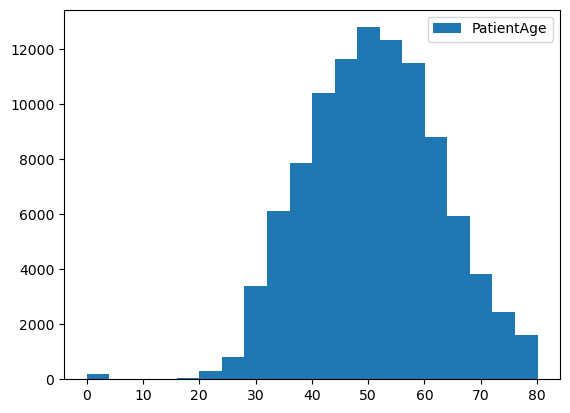

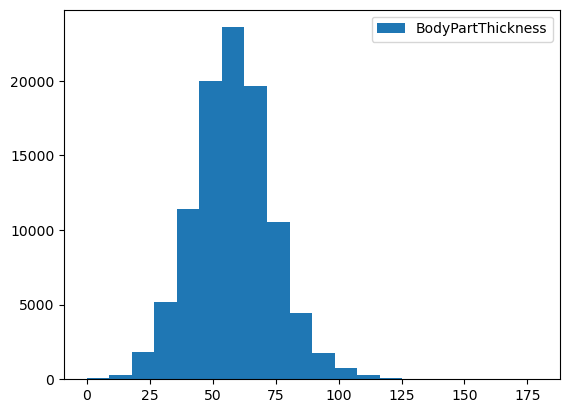

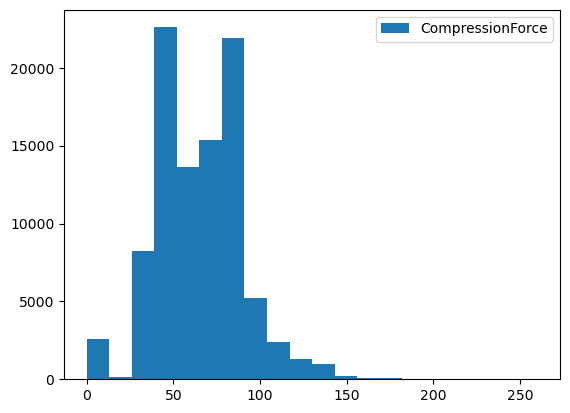

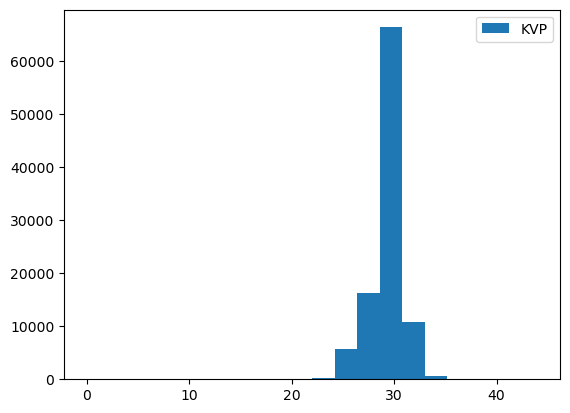

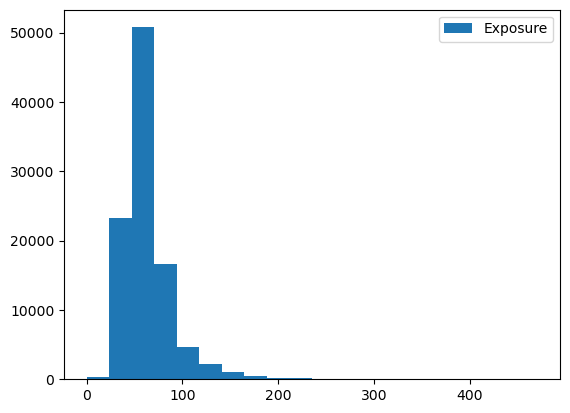

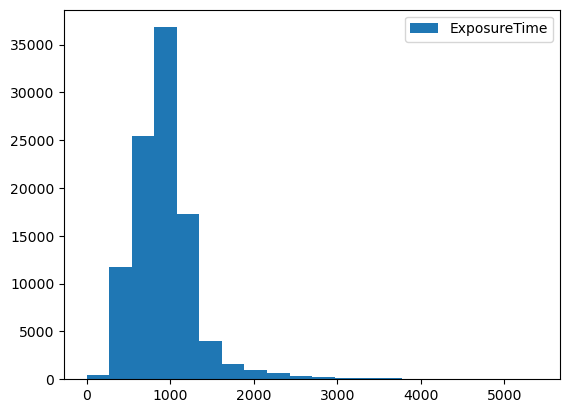

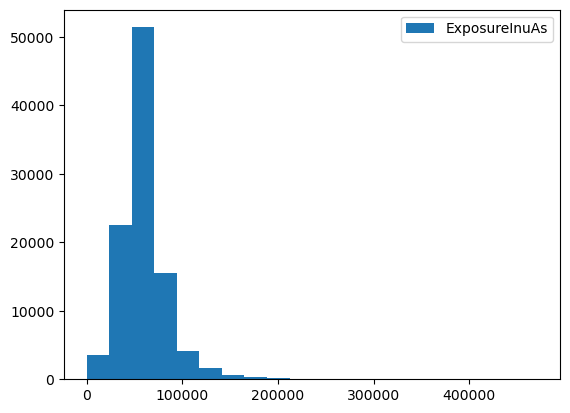

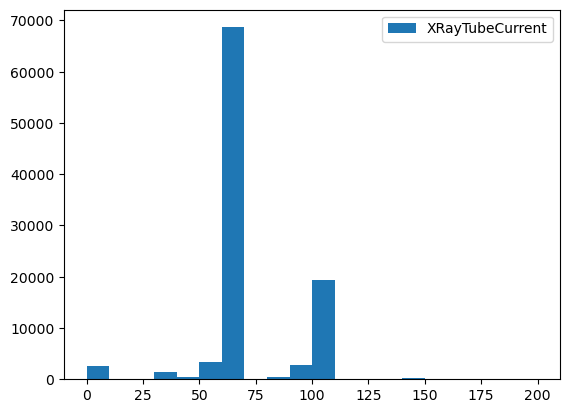

In [11]:
for field in record.keys() :
    if field in stats_fields.keys() :
        try:
            stats_fields[field].sort()
        except Exception as e:
            print(field, e)
            for v in stats_fields[field][:20]:
                print(type(v), repr(v))
        plt.figure()
        plt.hist(stats_fields[field], bins = 20, label = field)
        plt.legend()
        plt.show
    else : 
        print(field)
        for value, amount in record[field].items() :
            print(f"\t{value:<50}{amount}")

In [19]:
# Example for printing specifc useful fields
for i in range(5) :
    ds = pydicom.dcmread(files[i], stop_before_pixels=True)
    print_specific(ds)
    print()

Manufacturer                                      GE MEDICAL SYSTEMS
BitsStored                                        12
PhotometricInterpretation                         MONOCHROME2
PixelIntensityRelationship                        LOG
BreastImplantPresent                              NO

Manufacturer                                      GE MEDICAL SYSTEMS
BitsStored                                        12
PhotometricInterpretation                         MONOCHROME2
PixelIntensityRelationship                        LOG
BreastImplantPresent                              NO

Manufacturer                                      GE MEDICAL SYSTEMS
BitsStored                                        12
PhotometricInterpretation                         MONOCHROME2
PixelIntensityRelationship                        LOG
BreastImplantPresent                              NO

Manufacturer                                      GE MEDICAL SYSTEMS
BitsStored                                        12
Ph

In [13]:
## Read dicom header

In [14]:
dicom_path = "/raid/data01/deephealth/dh_dcm_ast/2.25.319977223756281645905941734320722144570/DXm.2.25.182315515521588145112612132423407523968"

if not os.path.exists(dicom_path):
    print(f"File not found: {dicom_path}")
    print("Please update dicom_path with a valid DICOM file path")
else:
    ds = pydicom.dcmread(dicom_path, stop_before_pixels=True)
    print(f"Found DICOM file {dicom_path}")
    print(f"Total DICOM elements: {len(ds)}")
    



Found DICOM file /raid/data01/deephealth/dh_dcm_ast/2.25.319977223756281645905941734320722144570/DXm.2.25.182315515521588145112612132423407523968
Total DICOM elements: 108


In [15]:
## Display dicom header

In [16]:
all_fields = []

for elem in ds:
    field_name = elem.name
    tag = str(elem.tag)
    
    try:
        value = elem.value
        if isinstance(value, bytes):
            value_str = f"<bytes: {len(value)} bytes>"
        elif isinstance(value, pydicom.sequence.Sequence):
            value_str = f"<Sequence: {len(value)} items>"
        else:
            value_str = str(value)
            if len(value_str) > 80:
                value_str = value_str[:80] + "..."
    except:
        value_str = str(type(elem.value))
    
    all_fields.append((field_name, tag, value_str))

all_fields.sort(key=lambda x: x[0])

print(f"{'Field Name':<50} {'Tag':<20} {'Value'}")
print("-" * 120)

for field_name, tag, value_str in all_fields:
    print(f"{field_name:<50} {tag:<20} {value_str}")

Field Name                                         Tag                  Value
------------------------------------------------------------------------------------------------------------------------
Accession Number                                   (0008,0050)          DHENZX7UWHI7
Acquisition Device Processing Code                 (0018,1401)          GEMS_FFDM_PV
Anatomic Region Sequence                           (0008,2218)          <Sequence: 1 items>
Anode Target Material                              (0018,1191)          RHODIUM
Bits Allocated                                     (0028,0100)          16
Bits Stored                                        (0028,0101)          12
Body Part Examined                                 (0018,0015)          BREAST
Body Part Thickness                                (0018,11A0)          94
Breast Implant Present                             (0028,1300)          NO
Burned In Annotation                               (0028,0301)          NO
Colli

In [17]:
## For printing specific field

In [18]:
def print_specific(ds) :
    useful_fields = [
        #"PatientAge",
        #"Rows", "Columns",
        #"BodyPartThickness", "CompressionForce", "KVP",
        #"ExposureTime", "ExposureInuAs", "XRayTubeCurrent",
        "Manufacturer",#, "ManufacturerModelName", "Modality", "PresentationIntentType",
        "BitsStored", "PhotometricInterpretation",# "RescaleSlope", "RescaleIntercept",
        "PixelIntensityRelationship",
        "BreastImplantPresent"
    ]

    record = {}

    for field in useful_fields:
        try:
            value = ds.get(field)
            if isinstance(value, bytes):
                value_str = f"<bytes: {len(value)} bytes>"
            elif isinstance(value, pydicom.sequence.Sequence):
                value_str = f"<Sequence: {len(value)} items>"
            else:
                value_str = str(value)
                if len(value_str) > 80:
                    value_str = value_str[:80] + "..."
        except:
            value_str = str(type(elem.value))
        record[field] = value_str
    
    for field, value in record.items() :
        print(f"{field:<50}{value}")

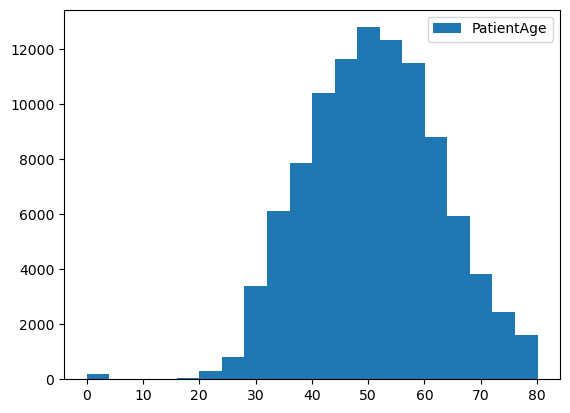

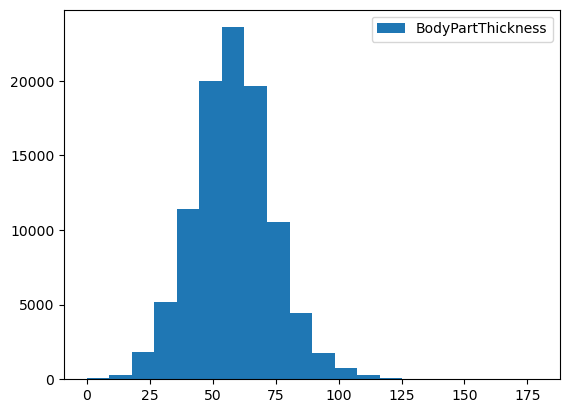

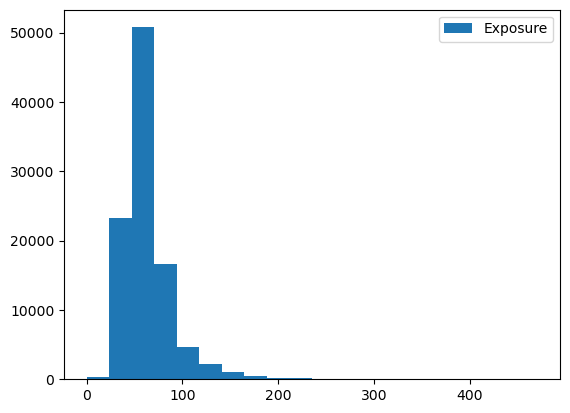

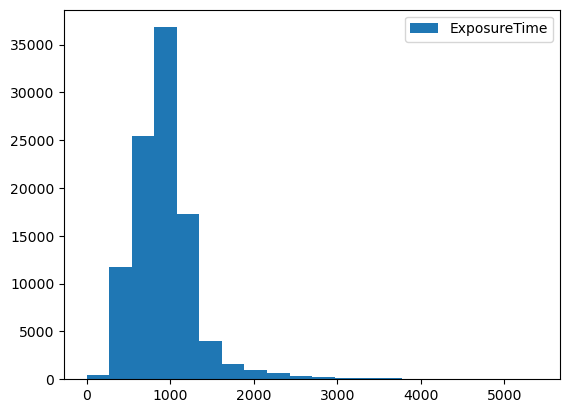

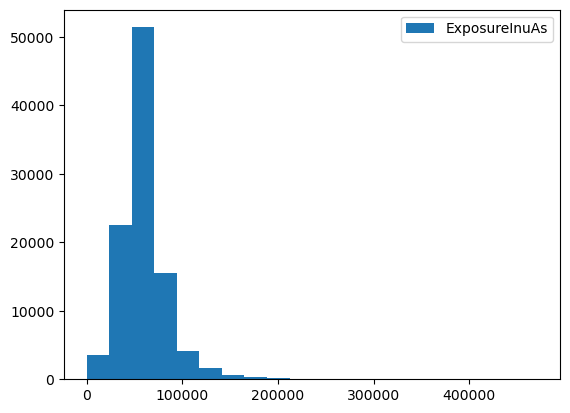

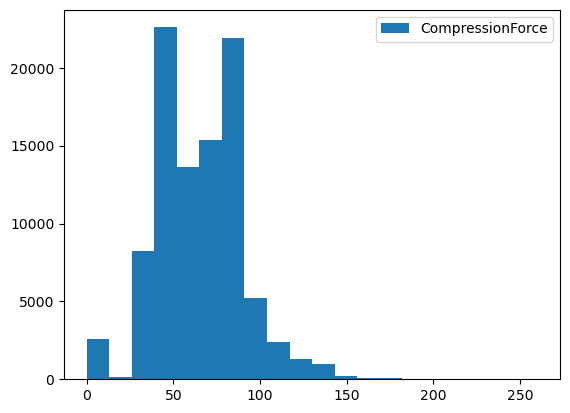

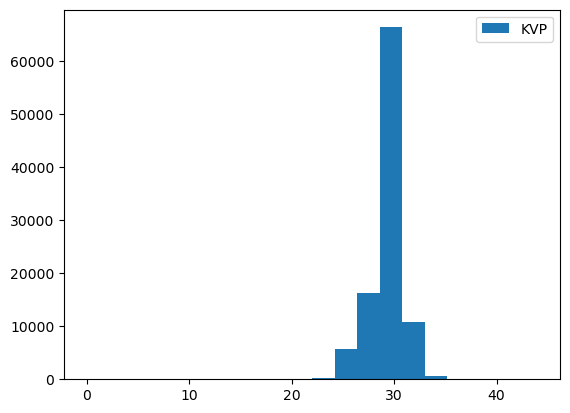

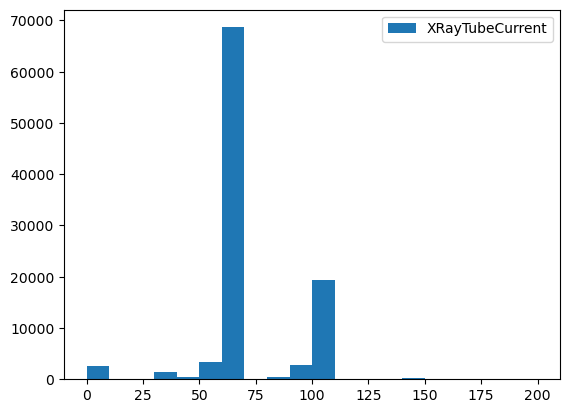

In [22]:
## Look through how breast thickness relates with exposure values

for field in stats_fields.keys() :
    stats_fields[field].sort()
    
    plt.figure()
    plt.hist(stats_fields[field], bins = 20, label = field)
    plt.legend()
    plt.show

In [56]:
omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid JSON file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")
    IDs = sorted([file.stem for file in omama_folder.rglob("*.json")])
    print(len(IDs))

Found DICOM folder: metadata
163568


In [57]:
print(IDs[0])
print(IDs[1])


100000039159562031368112550794429920461
100000201190603337191863609201535272336


In [60]:
with open("/home/anya.tongprasith001/U54REC/release_to_dicom_mapping.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    print(len(rows))
    print(rows[0]["release_id"])
    print(rows[1]["release_id"])

163568
100000039159562031368112550794429920461
100000201190603337191863609201535272336


In [62]:
i = 0
wrong = 0
check = True
for id in IDs :
    if id != rows[i]["release_id"] :
        #print(f"{id:<50}{rows[i]["release_id"]}")
        check = False
        wrong += 1
    i += 1
print(f"All same? {check}")
print(wrong)

All same? True
0
